# Week 4 - Linear Regression Baseline Model

A simple, interpretable baseline using numerical property characteristics only.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

plt.style.use("ggplot")

## Load Week 3 train and validation data

In [3]:
data_dir = Path(r"C:\\Users\\Richa\\OneDrive\\文档\\idx exchange")
week3_dir = data_dir / "week3_outputs"

train_df = pd.read_csv(week3_dir / "train_baseline_ready.csv")
validation_df = pd.read_csv(week3_dir / "validation_baseline_ready.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)

Train shape: (58770, 9)
Validation shape: (11907, 9)


## Select simple baseline features

These are physical or geographic property characteristics. Listing-price and sale-process fields are excluded.

In [4]:
target_col = "ClosePrice"

baseline_features = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "GarageSpaces",
    "Latitude",
    "Longitude",
]

X_train = train_df[baseline_features]
y_train = train_df[target_col]

X_validation = validation_df[baseline_features]
y_validation = validation_df[target_col]

print("Baseline features:", baseline_features)
print("Number of features:", len(baseline_features))

Baseline features: ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces', 'Latitude', 'Longitude']
Number of features: 8


## Train Linear Regression baseline

Missing-value imputation and feature standardization were already completed in Week 3 using training-set statistics only.

In [5]:
baseline_model = LinearRegression()

baseline_model.fit(X_train, y_train)
validation_predictions = baseline_model.predict(X_validation)

print("Baseline model trained.")

Baseline model trained.


## Evaluate on the validation month

In [6]:
absolute_percentage_error = (
    np.abs(y_validation - validation_predictions) / y_validation * 100
)

metrics = pd.DataFrame([{
    "R2": r2_score(y_validation, validation_predictions),
    "MAPE_percent": absolute_percentage_error.mean(),
    "MdAPE_percent": np.median(absolute_percentage_error),
    "MAE_dollars": mean_absolute_error(y_validation, validation_predictions),
}])

metrics.round(4)

,R2,MAPE_percent,MdAPE_percent,MAE_dollars
0,0.4708,44.5973,30.7342,466698.8527


## Visualize actual versus predicted prices

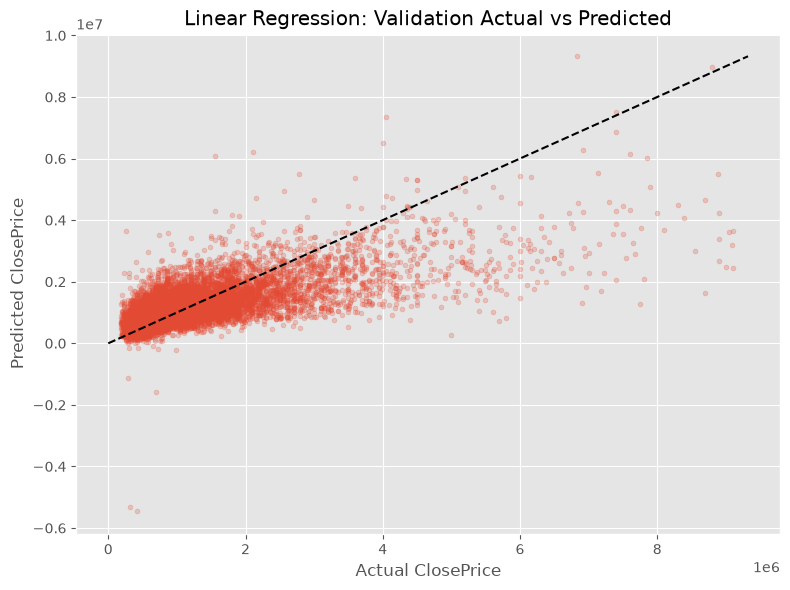

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(y_validation, validation_predictions, alpha=0.25, s=12)

plot_max = max(y_validation.max(), validation_predictions.max())
plt.plot([0, plot_max], [0, plot_max], color="black", linestyle="--")

plt.title("Linear Regression: Validation Actual vs Predicted")
plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.tight_layout()
plt.show()

## Week 4 summary

- Trained a simple Linear Regression baseline.
- Used eight numeric property and location features.
- Used Week 3 data, where missing values were filled with the training median and features were standardized.
- Evaluated performance on the validation month.
- The final test month remains untouched for later model selection and final evaluation.